# Negative Binomial Regression Model

BIC is metric because inference is the goal

In [ ]:
# Setup

import statsmodels.api as sm
import statsmodels.formula.api as smf
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import libpysal
from sklearn.preprocessing import StandardScaler
from glum import GeneralizedLinearRegressor, GeneralizedLinearRegressorCV
from itertools import combinations
from esda.moran import Moran
from spreg import ML_Lag
import sys, os
sys.path.append(os.path.abspath("..")) 
from src.nb_model import *

PRO_DATA_DIR = "../data/processed"
os.makedirs(PRO_DATA_DIR, exist_ok=True)

# Loading council district analysis dataframe
cc_analysis = gpd.read_file(f"{PRO_DATA_DIR}/cc_analysis.geojson")

**Correlation Matrix**

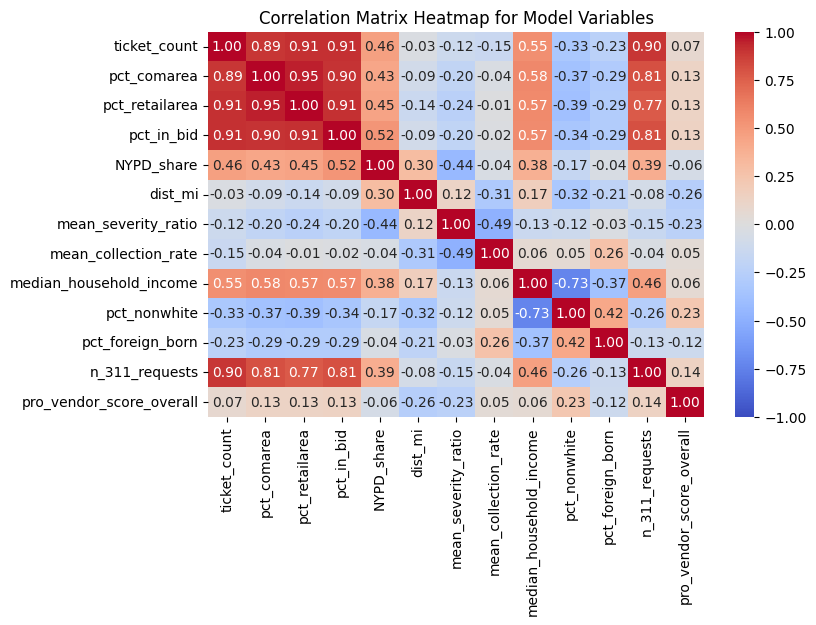

In [4]:
corr_matrix = cc_analysis[['ticket_count', 'pct_comarea', 'pct_retailarea', 
                           'pct_in_bid', 'NYPD_share', 'dist_mi', 'mean_severity_ratio',
                           'mean_collection_rate', 'median_household_income','pct_nonwhite',
                           'pct_foreign_born', 'n_311_requests', 'pro_vendor_score_overall',]].corr()


# Set up the visualization figure frame size
plt.figure(figsize=(8, 5))

# Plot the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    fmt=".2f"
)

plt.title('Correlation Matrix Heatmap for Model Variables')
plt.show()

In [10]:
print("Dispersion (var / mean):", cc_analysis['ticket_count'].var() / cc_analysis['ticket_count'].mean(), "\nNB appropriate")

Dispersion (var / mean): 10996.673736997833 
NB appropriate


**Standardizing Variables**

Chose pct comarea over retaila rea

In [5]:
# Set up x, y, and offset

model_df = cc_analysis.copy()
predictor_cols = ['pct_comarea', 'pct_in_bid', 
                  'NYPD_share', 'dist_mi', 'mean_severity_ratio',
                  'mean_collection_rate', 'median_household_income',
                  'pct_nonwhite', 'pct_foreign_born', 'n_311_requests', 
                  'pro_vendor_score_overall']

y = model_df['ticket_count'].values
offset = np.log(model_df['total_pop'].values)
X = model_df[predictor_cols].copy()

valid_mask = X.notna().all(axis=1) & ~np.isnan(y) & ~np.isnan(offset)
X = X.loc[valid_mask]
y = y[valid_mask.values]
offset = offset[valid_mask.values]

# Scaling variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Adding to model_df
scaled_cols = [f'{col}_z' for col in predictor_cols]
X_scaled_df = pd.DataFrame(X_scaled, columns=scaled_cols, index=X.index)

model_df = model_df.join(X_scaled_df)

## Testing All Possible Variable Combinations

In [ ]:
candidate_vars = [
    'pct_comarea_z',
    'pct_in_bid_z',
    'NYPD_share_z',
    'dist_mi_z',
    'mean_severity_ratio_z',
    'mean_collection_rate_z',
    'median_household_income_z',
    'pct_nonwhite_z',
    'pct_foreign_born_z',
    'n_311_requests_z',
    'pro_vendor_score_overall_z'
]

y = model_df['ticket_count']
offset = np.log(model_df['total_pop'])

results = []

# Test all subsets of optional vars (2^8 = 256 combinations)
for r in range(0, len(candidate_vars) + 1):
    for combo in combinations(candidate_vars, r):
        vars_in_model = list(combo)
        X = sm.add_constant(model_df[vars_in_model])
        try:
            model = sm.NegativeBinomial(y, X, offset=offset).fit(maxiter=200, disp=False)
            results.append({
                'vars': vars_in_model,
                'n_vars': len(vars_in_model),
                'bic': model.bic,
                'llf': model.llf
            })
        except Exception:
            pass  # skip combinations that fail to converge

results_df = pd.DataFrame(results).sort_values('bic').reset_index(drop=True)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/discrete/discrete_model.py:3615: RuntimeWarning: invalid value encountered in divide
  dada = (da2 * dalpha/da1 + da1**2 * (special.polygamma(1, a1+y) -
/Library/Frameworks/Python.framework/Versions/3.14/lib/pyth

In [8]:
styled_results(results_df, n=10)

## Backwards Selection for Variable Validation

In [11]:
# Run backward selection

final_model, selection_history, final_vars = backward_selection_nb(
    df=model_df,
    y_col='ticket_count',
    candidate_vars=candidate_vars,
    offset_col='total_pop',
    p_threshold=0.05,
    standardize=True
)

Round 1: 11 vars | BIC = 807.7244
  Best drop: 'pct_nonwhite_z' → BIC = 803.7976 (improvement)
Round 2: 10 vars | BIC = 803.7976
  Best drop: 'pct_comarea_z' → BIC = 799.9149 (improvement)
Round 3: 9 vars | BIC = 799.9149
  Best drop: 'mean_severity_ratio_z' → BIC = 796.1160 (improvement)
Round 4: 8 vars | BIC = 796.1160
  Best drop: 'NYPD_share_z' → BIC = 792.5764 (improvement)
Round 5: 7 vars | BIC = 792.5764
  Best drop: 'dist_mi_z' → BIC = 789.6649 (improvement)
Round 6: 6 vars | BIC = 789.6649
  Best drop: 'median_household_income_z' → BIC = 787.3598 (improvement)
Round 7: 5 vars | BIC = 787.3598
  Best drop: 'pct_foreign_born_z' → BIC = 784.1753 (improvement)
Round 8: 4 vars | BIC = 784.1753
  Best drop: 'mean_collection_rate_z' → BIC = 782.3580 (improvement)
Round 9: 3 vars | BIC = 782.3580
  Best drop: 'pro_vendor_score_overall_z' → BIC = 780.8914 (improvement)
Round 10: 2 vars | BIC = 780.8914
  Best drop: 'n_311_requests_z' → BIC = 784.9784 (no improvement)
  No removal impro

In [ ]:
# Report results
print("\n" + "=" * 60)
print("BACKWARD SELECTION SUMMARY")
print("=" * 60)
print(f"Number of rounds run: {len(selection_history)}")
print(f"Final BIC: {final_model.bic:.4f}")
print(f"Final variables ({len(final_vars)}):")
for v in final_vars:
    print(f"  - {v}")

print("\nDrop history:")
for r in selection_history:
    if r['dropped_var']:
        print(f"  Round {r['round']}: dropped '{r['dropped_var']}'")


BACKWARD SELECTION SUMMARY
Number of rounds run: 10
Final BIC: 780.8914
Final variables (2):
  - pct_in_bid_z
  - n_311_requests_z

Drop history:
  Round 1: dropped 'pct_nonwhite_z'
  Round 2: dropped 'pct_comarea_z'
  Round 3: dropped 'mean_severity_ratio_z'
  Round 4: dropped 'NYPD_share_z'
  Round 5: dropped 'dist_mi_z'
  Round 6: dropped 'median_household_income_z'
  Round 7: dropped 'pct_foreign_born_z'
  Round 8: dropped 'mean_collection_rate_z'
  Round 9: dropped 'pro_vendor_score_overall_z'

Final model summary:
                     NegativeBinomial Regression Results                      
Dep. Variable:           ticket_count   No. Observations:                   51
Model:               NegativeBinomial   Df Residuals:                       48
Method:                           MLE   Df Model:                            2
Date:                Tue, 04 Aug 2026   Pseudo R-squ.:                 0.09599
Time:                        09:58:00   Log-Likelihood:                -382.58

## Elastic Net Selection for Variable Validation

**K-Fold Cross Validation to find Lambda**

In [ ]:
# Setting model constants
X = model_df[candidate_vars]
y = model_df['ticket_count']
offset = np.log(model_df['total_pop'])

# Running model
model = GeneralizedLinearRegressorCV(
    family='negative.binomial', 
    l1_ratio=[0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    cv=5,
    random_state=42
)

model.fit(X, y, offset=offset)

# Reporting results
print(f"Optimal alpha (lambda): {model.alpha_}")
print(f"Optimal l1_ratio: {model.l1_ratio_}")
print(dict(zip(candidate_vars, model.coef_)))

Optimal alpha (lambda): 0.4904194861687326
Optimal l1_ratio: 0.0
{'pct_comarea_z': np.float64(0.19607428833404486), 'pct_in_bid_z': np.float64(0.2503002183034089), 'NYPD_share_z': np.float64(0.09296123706960498), 'dist_mi_z': np.float64(-0.11461512348343093), 'mean_severity_ratio_z': np.float64(-0.0139982508300259), 'mean_collection_rate_z': np.float64(-0.131405160047908), 'median_household_income_z': np.float64(0.1291946807838961), 'pct_nonwhite_z': np.float64(-0.01534049824636716), 'pct_foreign_born_z': np.float64(0.037456044934254897), 'n_311_requests_z': np.float64(0.26943402343059414), 'pro_vendor_score_overall_z': np.float64(0.10469112954639107)}


**RIDGE Regression**

In [25]:
# Setting model constants
X = model_df[candidate_vars]
y = model_df['ticket_count']
offset = np.log(model_df['total_pop'])

# Pure ridge: l1_ratio=0, using alpha found from CV search
ridge_model = GeneralizedLinearRegressor(
    family='negative.binomial',      
    l1_ratio=model.l1_ratio_,            
    alpha=model.alpha_        
)

ridge_model.fit(X, y, offset=offset)

# Build ranking table
ridge_coefs = pd.DataFrame({
    'variable': candidate_vars,
    'coefficient': ridge_model.coef_,
    'abs_coefficient': np.abs(ridge_model.coef_)
}).sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

ridge_coefs['rank'] = ridge_coefs.index + 1

print(ridge_coefs[['rank', 'variable', 'coefficient']])

    rank                    variable  coefficient
0      1            n_311_requests_z     0.269434
1      2                pct_in_bid_z     0.250300
2      3               pct_comarea_z     0.196075
3      4      mean_collection_rate_z    -0.131407
4      5   median_household_income_z     0.129193
5      6                   dist_mi_z    -0.114620
6      7  pro_vendor_score_overall_z     0.104690
7      8                NYPD_share_z     0.092961
8      9          pct_foreign_born_z     0.037453
9     10              pct_nonwhite_z    -0.015340
10    11       mean_severity_ratio_z    -0.014000


## Fitting Top 2 Models

**Model 1**

In [41]:
print("\nFinal model summary:")
print(final_model.summary())


Final model summary:
                     NegativeBinomial Regression Results                      
Dep. Variable:           ticket_count   No. Observations:                   51
Model:               NegativeBinomial   Df Residuals:                       48
Method:                           MLE   Df Model:                            2
Date:                Tue, 04 Aug 2026   Pseudo R-squ.:                 0.09599
Time:                        10:48:14   Log-Likelihood:                -382.58
converged:                       True   LL-Null:                       -423.21
Covariance Type:            nonrobust   LLR p-value:                 2.274e-18
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -1.6474      0.100    -16.498      0.000      -1.843      -1.452
pct_in_bid_z         0.5460      0.149      3.667      0.000       0.254       0.838
n_311_

**Model 2**

In [42]:
X_vars = ['n_311_requests_z', 'pct_in_bid_z', 'pro_vendor_score_overall_z']
X1 = sm.add_constant(model_df[X_vars])
offset1 = np.log(model_df['total_pop'])

m2 = sm.NegativeBinomial(
    model_df['ticket_count'],
    X1,
    offset = offset1
).fit(maxiter = 200, disp = False)

print("\nModel 2 summary:")
print(m2.summary())


Model 2 summary:
                     NegativeBinomial Regression Results                      
Dep. Variable:           ticket_count   No. Observations:                   51
Model:               NegativeBinomial   Df Residuals:                       47
Method:                           MLE   Df Model:                            3
Date:                Tue, 04 Aug 2026   Pseudo R-squ.:                 0.09891
Time:                        10:51:28   Log-Likelihood:                -381.35
converged:                       True   LL-Null:                       -423.21
Covariance Type:            nonrobust   LLR p-value:                 4.896e-18
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -1.6595      0.098    -16.968      0.000      -1.851      -1.468
n_311_requests_z               0.4824      0.185      2.614      

## Spatial Robustness and Spatial Lag Robustness Check

**Moran's I on `final_model` Residuals**

In [29]:
residuals = final_model.resid_pearson

# Create your spatial weights matrix
w = libpysal.weights.Queen.from_dataframe(cc_analysis)
w.transform = 'R'

# Calculate Global Moran's I on the residuals
mi = Moran(residuals, w, permutations = 999)

print(f"\nMoran's I: {mi.I:.4f}")
print(f"p-value: {mi.p_sim:.4f}\n")



Moran's I: -0.0390
p-value: 0.4600



/var/folders/dz/r3jh38h95rs7sxsc47pyxs980000gn/T/ipykernel_61998/2665864065.py:4: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(cc_analysis)


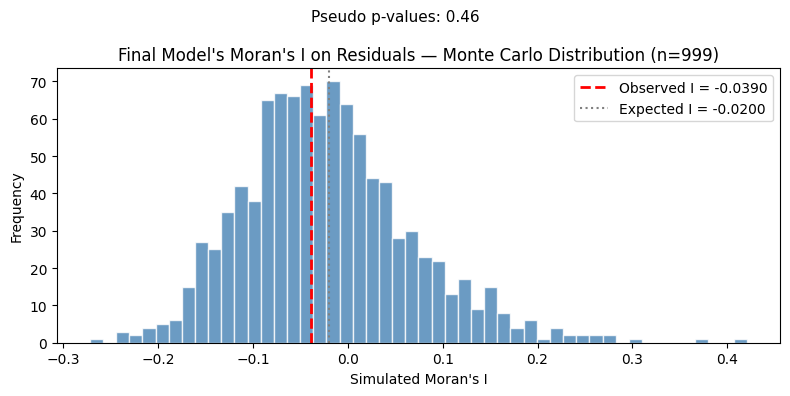

In [31]:
# Visualizing

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

ax.hist(mi.sim, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(mi.I, color="red", linestyle="--", linewidth=2, label=f"Observed I = {mi.I:.4f}")
ax.axvline(mi.EI, color="gray", linestyle=":", linewidth=1.5, label=f"Expected I = {mi.EI:.4f}")
ax.set_title(f"Final Model's Moran's I on Residuals — Monte Carlo Distribution (n={mi.permutations})")
ax.set_xlabel("Simulated Moran's I")
ax.set_ylabel("Frequency")
ax.legend()

plt.suptitle(f"Pseudo p-values: {mi.p_sim}", fontsize=11)
plt.tight_layout()
plt.show()

**Spatial Lag Robustness Check**

In [ ]:
X = model_df[candidate_vars].values
y = np.log(model_df['ticket_count']).values.reshape(-1, 1)

# Offset: spreg doesn't natively support offsets, so fold it in manually
y_adj = y - np.log(model_df['total_pop'].values).reshape(-1, 1)

model_lag = ML_Lag(
    y_adj, X,
    w=w,               # Queen weights object
    name_y='log_violations',
    name_x=candidate_vars,
    name_w='queen_weights',
    name_ds='model_df'
)

print(model_lag.summary)

ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :    model_df
Weights matrix      :queen_weights
Dependent Variable  :log_violations                Number of Observations:          51
Mean dependent var  :     -1.9234                Number of Variables   :          13
S.D. dependent var  :      1.2682                Degrees of Freedom    :          38
Pseudo R-squared    :      0.6751
Spatial Pseudo R-squared:  0.6783
Log likelihood      :    -55.4262
Sigma-square ML     :      0.5124                Akaike info criterion :     136.852
S.E of regression   :      0.7158                Schwarz criterion     :     161.966

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
----------------------------------

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2406: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


## Hierarchical Linear Modeling

In [37]:
# Making a log_dist_km column
model_df['log_dist_km'] = np.log(model_df['dist_mi'])

# Null mixed model
m_null = smf.mixedlm(
    "log_dist_km ~ 1",
    data=model_df,
    groups=model_df["ticket_count"]
).fit(reml=True)

# Extract variance components
var_between = m_null.cov_re.iloc[0, 0]   # random intercept variance (between districts)
var_within  = m_null.scale                # residual variance (within districts)

icc = var_between / (var_between + var_within)

print(f"ICC = {icc:.3f} — {icc*100:.1f}% of distance variance is between districts\n")

ICC = 0.500 — 50.0% of distance variance is between districts



/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


Multilevel modeling is strongly justified

**Model 4**

In [ ]:
import statsmodels.formula.api as smf
import pandas as pd
import numpy as np
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# Fit with increased iterations to help convergence
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    m_dist = smf.mixedlm("log_dist_km ~ Q('n_311_requests_z') + pct_in_bid_z",
      data=model_df,
      groups=model_df["ticket_count"]
      ).fit(reml=False)

print(m_dist.summary()) 

             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   log_dist_km
No. Observations:    51        Method:               ML         
No. Groups:          51        Scale:                0.0476     
Min. group size:     1         Log-Likelihood:       -12.3703   
Max. group size:     1         Converged:            Yes        
Mean group size:     1.0                                        
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              1.895    0.040 47.711 0.000  1.817  1.973
Q('n_311_requests_z')  0.008    0.052  0.151 0.880 -0.093  0.109
pct_in_bid_z          -0.023    0.029 -0.780 0.435 -0.080  0.035
Group Var              0.048                                    



**Saving Processed Datasets**